In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import quantstats as qs
import empyrical as ep
import os
import matplotlib.pyplot as plt; plt.rcdefaults()

In [2]:
# !pip install fanchart
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [3]:
# !pip install -e /Users/safishajjouz/GitHub/QuantitativePortfolioManagement
# set env to: jupyter_env 
from maData.getdata import get_US_yields, get_fx
from myPortfolioManagement.myData import get_stock_prices
from myPortfolioManagement.myTimeSeries import make_sma
from myPortfolioManagement.myBacktesting import performance, prep_dist, plot_fan_chart
from myPortfolioManagement.myPerformanceMetrics import performance_overview, get_main_stats
from myPortfolioManagement.myPlots import monthly_heatmap
from myPortfolioManagement.myBootstrapping import bootstrappingTS
from myPortfolioManagement.myReturns import returns_from_prices

In [4]:
# download US Yields
# ======================================================================================================================
df_USyields = get_US_yields(freq='d', add_fed_rate=True)

# define slope
# ======================================================================================================================
df = df_USyields[['2Y', 'DFF', '1Y']].copy()
df['Slope2Y'] = df['DFF'] - df['2Y']  # if 2Y > DFF, means markets expect Fed to increase rates

<Axes: xlabel='Date'>

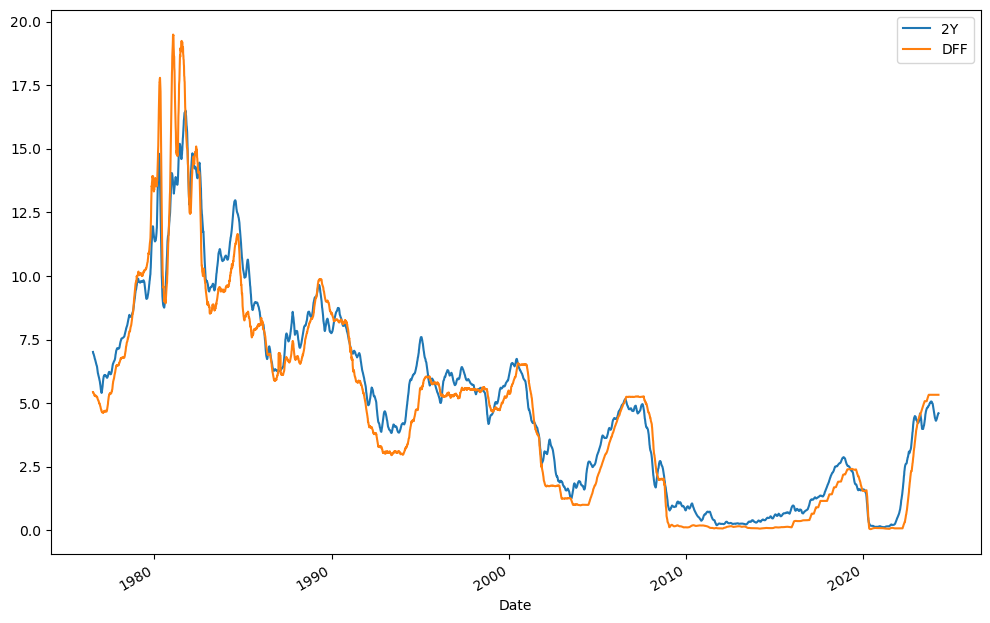

In [5]:
# check
df[['2Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot(figsize= (12,8))

In [6]:
# define momentum
# ======================================================================================================================
df_sm = make_sma(df[['Slope2Y']], spans=[50])
df_all = df.join(df_sm).dropna()

# generate signal
# ======================================================================================================================
df_all['Signal_ls'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, -1)
df_all['Signal_ln'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, 0)

<Axes: xlabel='Date'>

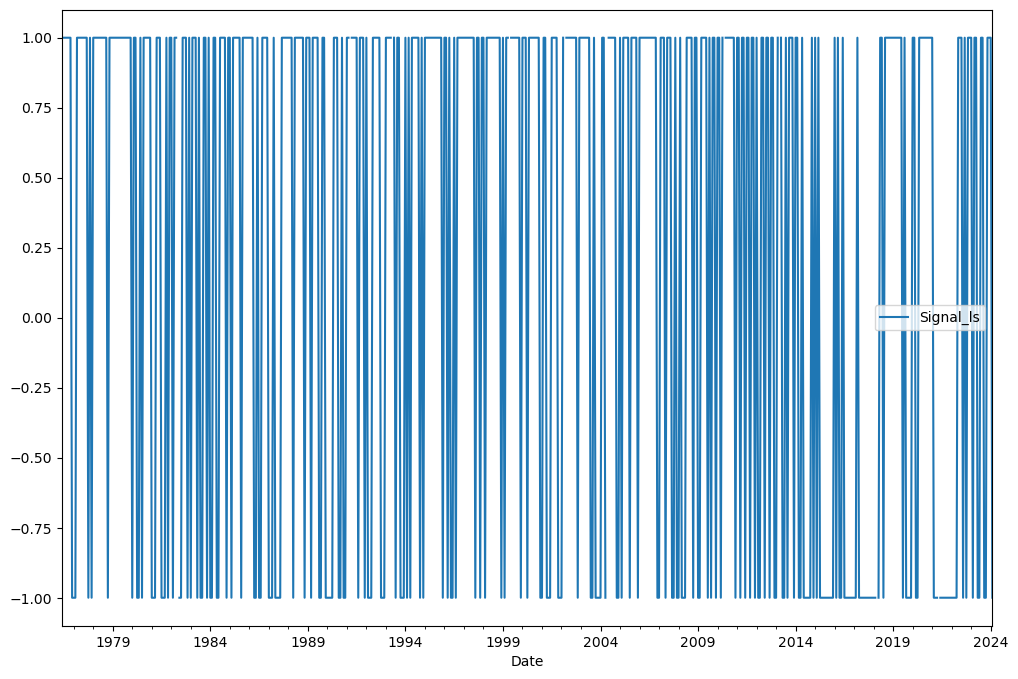

In [7]:
df_all[['Signal_ls']].dropna().asfreq('BM').plot(figsize=(12,8))

In [8]:
df_all[['Signal_Action']] = np.where(df_all[['Signal_ls']]==1, 'Buy USD', 'Buy Yen')

array([['Buy Yen'],
       ['Buy Yen'],
       ['Buy USD'],
       ...,
       ['Buy Yen'],
       ['Buy Yen'],
       ['Buy USD']], dtype='<U7')

In [9]:
# Get data trading instruments: EURUSD, Stocks, Japan
# ======================================================================================================================
df_stock = get_stock_prices(yahoo_tickers=['^IXIC'], wide_format=True)
df_stock = df_stock.rename(columns={'^IXIC': 'Nasdaq'})
#df_fx = get_FX_spots(currencies=['EUR', 'JPY'], wide_format=True)
df_fx = get_fx(cross = "JPYUSD")

df_assets = pd.concat([df_stock, df_fx], axis=1)
df_assets.index.name = df_all.index.name

# merge all
# ======================================================================================================================
df_all = df_all.join(df_assets)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 7752.87it/s]

get_stock_prices took 1.345sec


<Axes: ylabel='Density'>

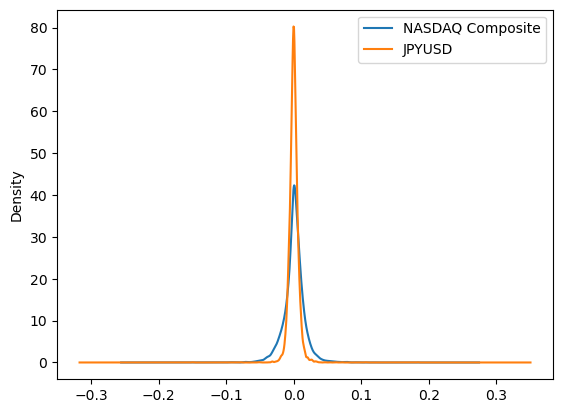

In [10]:
returns_from_prices(df_assets).dropna().plot.density()

<Axes: xlabel='Date'>

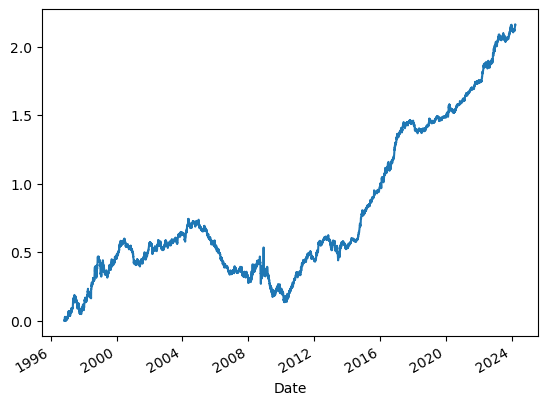

In [11]:
performance(signal=df_all['Signal_ls'], returns=df_all['JPYUSD'].pct_change()).dropna().cumsum().plot()

In [12]:
# performance
# ======================================================================================================================
df_perm = pd.DataFrame(index=df_all.index)
for col in ['JPYUSD']:
    # df_perm[col] = performance(signal=df_all['Signal'], returns=np.log(df_all[col]).diff()).cumsum()
    ret_temp = returns_from_prices(df_all[col])
    df_perm[col] = performance(signal=df_all['Signal_ls'], returns=ret_temp)
    #df_perm[col + '_no_TC'] = performance(signal=df_all['Signal_ls'], returns=ret_temp, bps=0)
    df_perm[col + '_ln'] = performance(signal=df_all['Signal_ln'], returns=ret_temp)
    # df_perm[col + 'str2'] = performance(signal=df_all['Signal2'], returns=np.log(df_all[col]).diff())

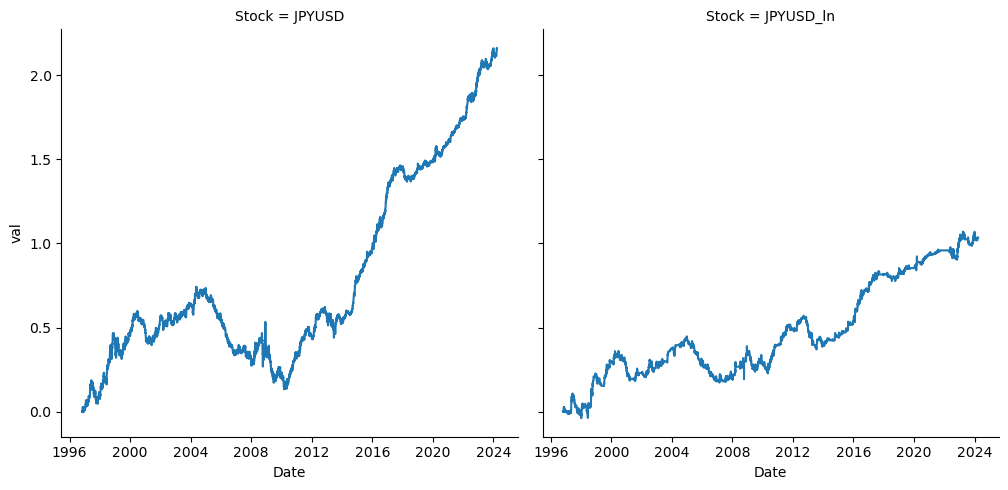

In [13]:
# from wide to long to plot
# ======================================================================================================================
dfm = df_perm.cumsum().dropna().reset_index().melt(id_vars='Date', var_name='Stock', value_name='val')
dfm['asset'] = [x.split('str')[0] for x in dfm.Stock]
g = sns.relplot(data=dfm, x='Date', y='val', col='Stock', col_wrap=3, kind='line')

In [14]:
# stats
df_perm_stats = performance_overview(df_perm, short=True).sort_values(by=['cagr'], ascending=False)
df_perm_stats

,start,end,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
JPYUSD,1996-10-31 00:00:00,2024-03-25 00:00:00,6.130958,0.074334,-0.498288,0.585938,1.586375,0.149179
JPYUSD_ln,1996-10-31 00:00:00,2024-03-25 00:00:00,1.568067,0.035024,-0.243313,0.42251,0.987866,0.143946


In [15]:
ret_bench = df_stock.pct_change()
df_temp = df_perm.join(ret_bench).dropna()

In [16]:
pd.options.display.float_format = '{:.2%}'.format
qs.stats.monthly_returns(returns=df_perm[['JPYUSD']].dropna(), eoy=True)

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,EOY
1996,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.33%,2.42%,2.77%
1997,3.56%,-1.79%,1.26%,3.09%,6.43%,0.38%,-3.11%,-3.36%,-2.12%,0.76%,0.10%,2.04%,6.98%
1998,3.70%,0.59%,6.78%,-0.34%,-2.14%,8.84%,2.82%,3.11%,1.76%,3.90%,6.15%,-4.48%,34.38%
1999,-8.48%,7.99%,-3.42%,-2.08%,-0.67%,-0.25%,6.52%,-1.57%,1.57%,2.10%,3.52%,-0.85%,3.34%
2000,4.03%,1.73%,7.02%,-1.21%,-0.17%,1.53%,-4.40%,0.28%,-1.35%,-0.61%,-0.35%,-3.54%,2.46%
2001,-5.49%,-1.05%,2.37%,-1.32%,-3.46%,4.43%,-2.27%,4.55%,-0.40%,1.10%,2.83%,6.61%,7.42%
2002,0.40%,-3.65%,-0.51%,0.53%,-1.20%,3.80%,-0.22%,1.14%,-2.79%,-1.14%,1.25%,4.50%,1.83%
2003,-3.76%,1.04%,1.92%,-0.74%,-0.40%,2.56%,1.40%,-3.59%,4.80%,1.39%,1.66%,-0.34%,5.75%
2004,-1.56%,-4.28%,5.62%,6.71%,-0.52%,-1.18%,1.41%,2.01%,-0.83%,0.61%,-1.30%,0.11%,6.48%
2005,-3.63%,-1.31%,0.28%,2.51%,-3.46%,-1.52%,-1.06%,-3.21%,-2.48%,0.91%,-2.97%,-0.23%,-15.21%


In [ ]:
qs.stats.monthly_returns(returns=df_temp[['NASDAQ Composite']], eoy=True)

In [ ]:
monthly = df_temp.resample('M').last()
monthly.boxplot()

In [ ]:
get_main_stats(df_temp[df_temp.index>='2012-01-01'])

In [ ]:
ret_boostp = bootstrappingTS(df_perm['JPYUSD'].dropna(), n_samples=10000, bootstrap_type='mbb', block_size=365*2, 
                             optimal_block = False, 
                                          seed=123)

In [ ]:
stats_boostp = get_main_stats(ret_boostp)
stats_boostp[['cagr']].plot.density()

In [ ]:
df_hist = get_main_stats(df_temp)
df_hist

In [ ]:
boost_mean = ret_boostp.resample('Y').last().mean().mean()

In [ ]:
hist_ret = returns_from_prices(df_assets['JPYUSD']).resample('Y').last().dropna()

In [ ]:
sns.distplot(ret_boostp.resample('Y').last().mean(), hist=True)
plt.axvline(x=hist_ret.mean(), color='g', linestyle='-', label='Historical')
plt.axvline(x=boost_mean, color='r', linestyle='--', label='Expected')
plt.title('Expected Returns(%)')
plt.legend()

In [ ]:
metric = 'sharpe'
hist_sharp = df_hist.loc['JPYUSD']['sharpe']
boost_sharp = stats_boostp[['sharpe']].mean()[0]
sns.distplot(stats_boostp[metric], hist=True)
plt.axvline(x=hist_sharp, color='r', linestyle='-', label = 'Historical Sharp')
plt.axvline(x=boost_sharp, color='g', linestyle='-', label = 'Expected Sharp')
plt.title('Expected Sharp')
plt.legend()

In [ ]:
hist_ret.index = pd.to_datetime(hist_ret.index).normalize()
sns.distplot(hist_ret*100, hist=True)

In [ ]:
 qs.reports.full(df_temp['JPYUSD'], benchmark=df_temp['NASDAQ Composite'], rf=0.05)

In [ ]:
qs.reports.full(df_temp['JPYUSD_ln'], benchmark=df_temp['NASDAQ Composite'], rf=0.05)

In [ ]:
dist = prep_dist(ret_boostp)

In [ ]:
dist['0.95'].plot()

In [ ]:
dist_cum = ep.cum_returns(dist, starting_value=1)

In [ ]:
pd.set_option('display.float_format', str)
round(dist_cum['0.95'],2)

In [ ]:
plot_fan_chart(df_temp[['JPYUSD']],dist_cum, out_of_sample_date='2023-05-12',
                   starting_value=1,
                   chart_title='Expected Returns')

In [ ]:
from fanchart import load_boe_history, load_boe_parameters
from fanchart import fan

history = load_boe_history()
parameters = load_boe_parameters()
    

In [ ]:
history

In [ ]:
probs = [0.05, 0.20, 0.35, 0.65,0.80,  0.95]
parameters

In [ ]:
fan(pars=parameters, probs=probs, historic=history[history.Date >= '2018'])

In [ ]:
param = pd.concat([ret_boostp.median(axis=1), ret_boostp.std(axis=1), ret_boostp.skew(axis=1)], axis=1)
param.columns = ['Mode','Uncertainty', 'Skewness']
param = param.reset_index()
param

In [ ]:
hist = df_temp[['JPYUSD']].reset_index()
hist = hist.rename(columns={'JPYUSD':'Inflation'})
fan(pars=param, probs=probs, historic=hist[hist.Date >= '2020'])